In [2]:
# Import required modules
import os
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import requests
from pycocotools.coco import COCO
from PIL import Image
import matplotlib.pyplot as plt
from io import BytesIO

In [3]:
import os

# Define the directory paths
annotation_dir = '/content/annotations'
image_dir = '/content/images'

# Create the directories if they do not exist
os.makedirs(annotation_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)


In [4]:
!wget -q -P /content/annotations http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q /content/annotations/annotations_trainval2017.zip -d /content/annotations


In [5]:
import os

# Define the path to the annotations file
annotations_file = '/content/annotations/annotations/instances_val2017.json'

# Check if the file exists
if os.path.exists(annotations_file):
    print(f"Annotations file found at: {annotations_file}")
else:
    print(f"Annotations file not found at: {annotations_file}")


Annotations file found at: /content/annotations/annotations/instances_val2017.json


In [9]:
ANNOTATION_FILE = '/content/annotations/annotations/instances_val2017.json'

loading annotations into memory...
Done (t=0.79s)
creating index...
index created!


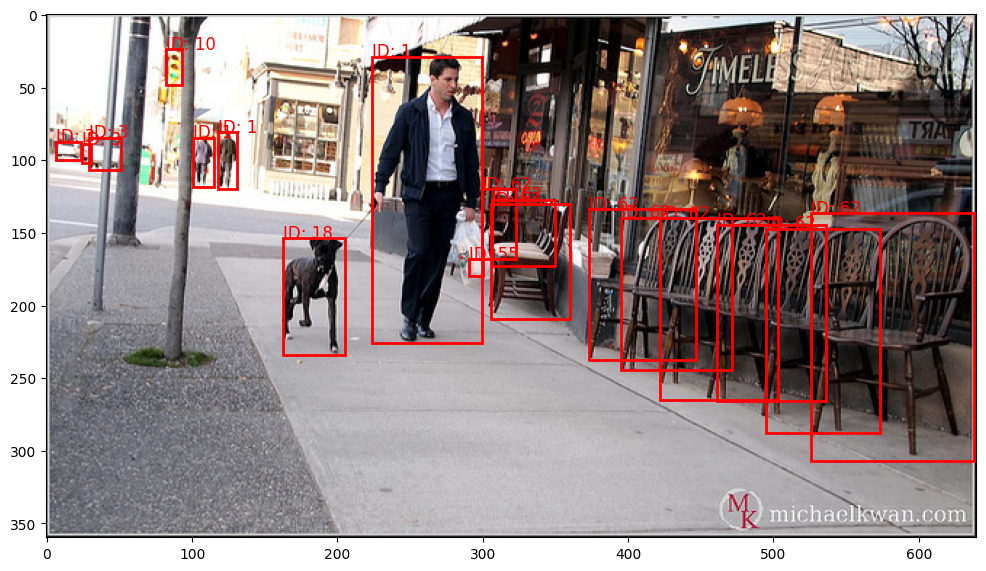

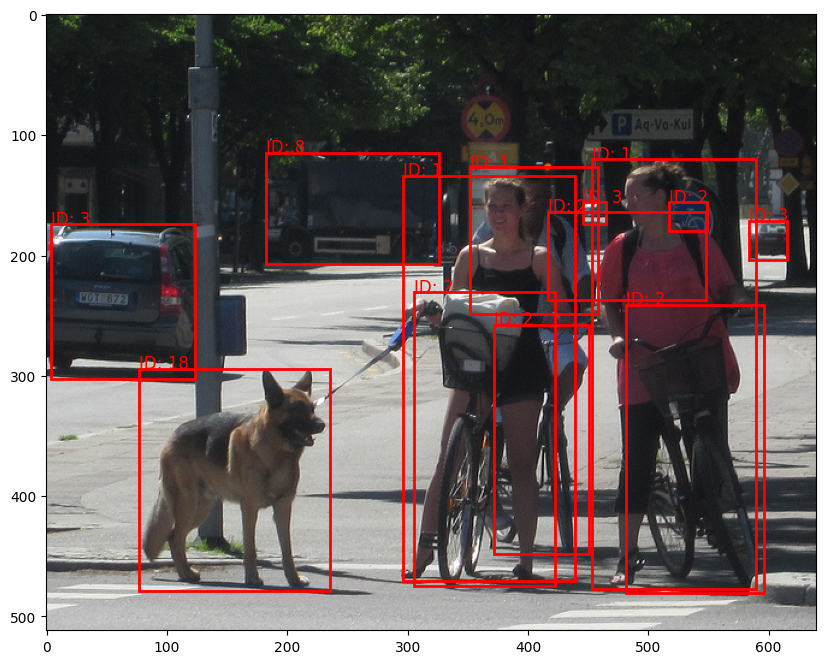

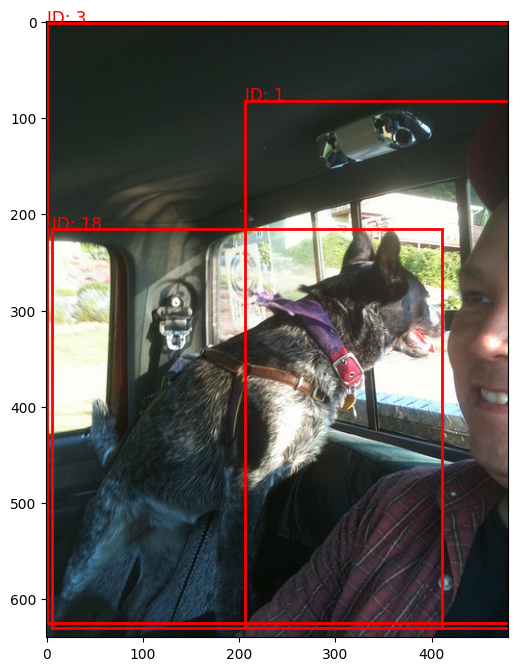

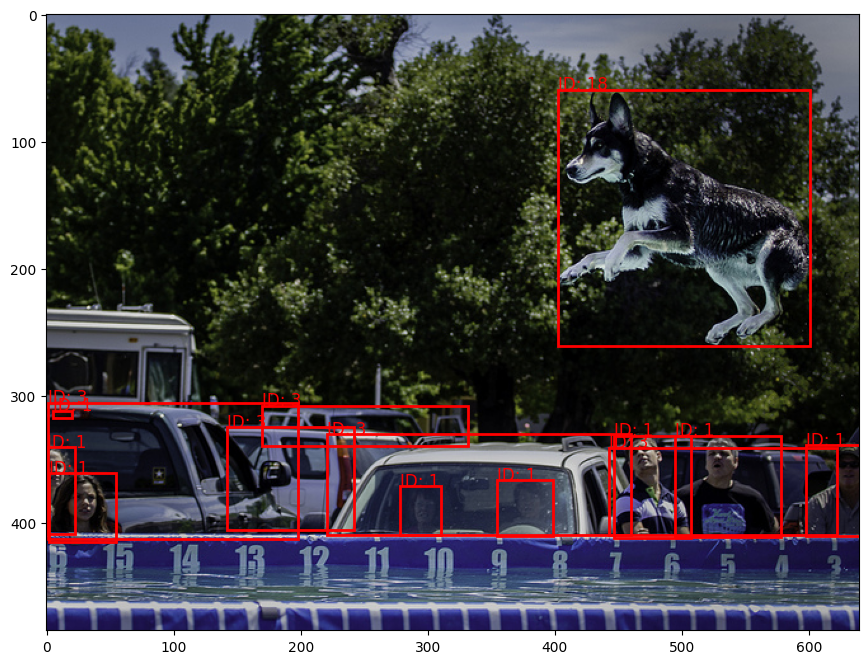

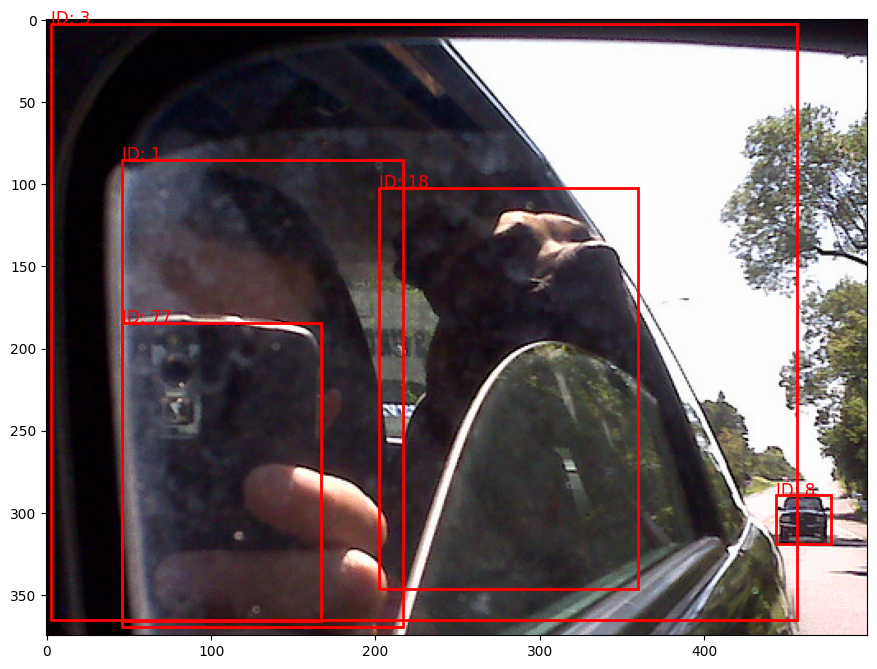

KeyError: 'default'

In [10]:

# Initialize COCO API for image annotations
coco = COCO(ANNOTATION_FILE)

# Define categories of interest (e.g., 'person', 'car', 'dog')
categories_of_interest = ['person', 'car', 'dog']
cat_ids = coco.getCatIds(catNms=categories_of_interest)
img_ids = coco.getImgIds(catIds=cat_ids)

# Select a subset of images (e.g., first 5 images)
subset_img_ids = img_ids[:5]
images = coco.loadImgs(subset_img_ids)

# Function to download and preprocess images
def load_image(image_info):
    image_url = image_info['coco_url']
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content))
    image = image.convert('RGB')
    return np.array(image)

# Function to display image with annotations
def display_image_with_annotations(image, image_info, annotations):
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    ax = plt.gca()
    for ann in annotations:
        bbox = ann['bbox']
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        plt.text(bbox[0], bbox[1], f"ID: {ann['category_id']}", color='red', fontsize=12)
    plt.show()

# Load and display images with annotations
for image_info in images:
    image = load_image(image_info)
    ann_ids = coco.getAnnIds(imgIds=image_info['id'])
    anns = coco.loadAnns(ann_ids)
    display_image_with_annotations(image, image_info, anns)

# Load a pre-trained object detection model from TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
model = hub.load(model_url).signatures['default']

# Function to run inference
def run_inference(model, image_np):
    image_tensor = tf.convert_to_tensor(image_np)
    image_tensor = image_tensor[tf.newaxis,...]
    output_dict = model(image_tensor)
    num_detections = int(output_dict.pop('num_detections'))
    output_dict = {key:value[0, :num_detections].numpy() for key,value in output_dict.items()}
    output_dict['num_detections'] = num_detections
    return output_dict

# Evaluate the model on the subset of images
for image_info in images:
    image = load_image(image_info)
    output_dict = run_inference(model, image)
    # Display the image with detections
    display_image_with_annotations(image, image_info, output_dict['detection_boxes'])
    # Here, you can implement code to calculate accuracy metrics such as IoU, precision, recall, etc.
    # For simplicity, we're just displaying the output_dict.
    print(output_dict)
